In [ ]:
############################################################################
# Created by:Timo Szczepanska
# UiT The Arctic University of Norway
# email:  tsz000@uit.no
# Sources: Scopus, ..
############################################################################

In [21]:
# Import other libraries
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs

# Options for plots
plt.rcParams['figure.figsize'] = (10, 6)
sbs.set('paper')

# Import litstudy
path = os.path.abspath(os.path.join('..'))
if path not in sys.path:
    sys.path.append(path)

import litstudy

In [22]:
# Load BibTeX
bib_docs = litstudy.load_bibtex("science_direct_29062026_210.bib")
print(len(bib_docs), "papers loaded from ScienceDirect")

# To merge the two document sets
# docs_csv = bib_docs | docs_springer | etc

210 papers loaded from ScienceDirect


In [27]:
# Define keywords
keyword_groups = {
    "MANDATORY": ["fisheries"],  # must be present
    "OR_phrases": ["futures studies", "future study", "megatrends", "weak signal", "future scenario"],
    "AND_drivers_trends_signals": ["drivers", "trends", "signals"]
}

# Flatten all keywords for total counts
all_keywords = [kw for group in keyword_groups.values() for kw in group]


In [28]:
# helper function
# ======================================
def count_phrase_occurrences(text, phrase):
    if not text:
        return 0
    return text.lower().count(phrase.lower())


In [29]:
#  filtered docs
filtered_docs = []
total_occurrences = {k: 0 for k in all_keywords}
article_hits = {k: 0 for k in all_keywords}

for doc in bib_docs:
    # Get abstract safely
    abstract = getattr(doc, "abstract", None)
    if abstract is None and hasattr(doc, "fields"):
        abstract = doc.fields.get("abstract", "")
    if abstract is None:
        abstract = ""
    
    abstract_lower = abstract.lower()
    
    # Count total occurrences and per-article hits
    for kw in all_keywords:
        c = count_phrase_occurrences(abstract, kw)
        total_occurrences[kw] += c
        if c > 0:
            article_hits[kw] += 1
    
    # Filter logic: mandatory AND (OR or AND)
    mandatory_ok = all(kw.lower() in abstract_lower for kw in keyword_groups.get("MANDATORY", []))
    or_ok = any(kw.lower() in abstract_lower for kw in keyword_groups.get("OR_phrases", []))
    and_ok = all(kw.lower() in abstract_lower for kw in keyword_groups.get("AND_drivers_trends_signals", []))
    
    if mandatory_ok and (or_ok or and_ok):
        filtered_docs.append(doc)

print(len(filtered_docs), "papers after filtering")

42 papers after filtering


In [30]:
# Initialize counters for filtered articles
filtered_article_hits = {k: 0 for k in all_keywords}

# Combined group counters
filtered_article_hits["OR_group"] = 0
filtered_article_hits["AND_group"] = 0

for doc in filtered_docs:
    abstract = getattr(doc, "abstract", None)
    if abstract is None and hasattr(doc, "fields"):
        abstract = doc.fields.get("abstract", "")
    if abstract is None:
        abstract = ""
    
    abstract_lower = abstract.lower()
    
    # Track individual keywords
    for kw in all_keywords:
        if count_phrase_occurrences(abstract, kw) > 0:
            filtered_article_hits[kw] += 1
    
    # Combined OR group (any OR keyword present)
    if any(kw.lower() in abstract_lower for kw in keyword_groups.get("OR_phrases", [])):
        filtered_article_hits["OR_group"] += 1
    
    # Combined AND group (all AND keywords present)
    if all(kw.lower() in abstract_lower for kw in keyword_groups.get("AND_drivers_trends_signals", [])):
        filtered_article_hits["AND_group"] += 1

# Build sorted order: MANDATORY first, then OR, then AND group
sorted_keys = (
    keyword_groups.get("MANDATORY", []) +
    keyword_groups.get("OR_phrases", []) +
    ["OR_group"] +
    keyword_groups.get("AND_drivers_trends_signals", []) +
    ["AND_group"]
)

print("=== Keyword counts in filtered articles ===")
for k in sorted_keys:
    v = filtered_article_hits.get(k, 0)
    print(f"{k}: {v}")

=== Keyword counts in filtered articles ===
fisheries: 42
futures studies: 0
future study: 2
megatrends: 1
weak signal: 0
future scenario: 37
OR_group: 40
drivers: 4
trends: 9
signals: 2
AND_group: 2


In [32]:
# save to database
articles_data = []
for doc in filtered_docs:
    row = {}
    for attr in dir(doc):
        if attr.startswith("_"):
            continue
        value = getattr(doc, attr)
        if callable(value):
            continue
        # Convert authors to string if necessary
        if isinstance(value, list) and len(value) > 0 and hasattr(value[0], "name"):
            value = ", ".join([a.name for a in value])
        row[attr] = value
    
    # Add keyword counts per article
    abstract = getattr(doc, "abstract", "") or ""
    for kw in all_keywords:
        row[f"count_{kw.replace(' ', '_')}"] = count_phrase_occurrences(abstract, kw)
    
    articles_data.append(row)

df_articles = pd.DataFrame(articles_data)


,abstract,affiliations,authors,citation_count,citations,entry,id,key,keywords,language,...,count_fisheries,count_futures_studies,count_future_study,count_megatrends,count_weak_signal,count_scenario,count_drivers,count_trends,count_signals,count_future_scenario
0,"This study presents emission data (CO2, NOx, C...",[],"Ziegler, Friederike, Hansson, Per-Anders",None,None,"{'pages': '303--314', 'keywords': 'Cod fishery...",<Emissions from fuel combustion in Swedish cod...,ziegler_emissions_2003,"[cod fishery, emissions, energy consumption, f...",None,...,3,0,0,0,0,2.0,0,0,0,NaN
1,Small-scale fishing communities are expected t...,[],"Silas, Mathew O., Mgeleka, Said S., Polte, Pat...",None,None,"{'pages': '67--76', 'keywords': 'Adaptation, C...",<Adaptive capacity and coping strategies of sm...,silas_adaptive_2020,"[adaptation, climate change, coastal communiti...",None,...,5,0,0,0,0,1.0,0,1,0,NaN
2,Fisheries are an important resource in many co...,[],"Lennert, Ann Eileen, Richard, Gaëtan",None,None,"{'pages': '272--281', 'keywords': 'Climate cha...",<At the cutting edge of the future: Unravellin...,lennert_at_2017,"[climate change, cultural practices, economic ...",None,...,3,0,0,0,0,1.0,0,0,0,NaN
3,This study conducts a comprehensive evaluation...,[],"Elahi, Ehsan, Li, Yuge, Emam, Ali Md, Zhu, Min...",None,None,"{'pages': '107471', 'keywords': 'Developing co...",<A systematic review of fish trade and its imp...,elahi_systematic_2024,"[developing countries, economic significance, ...",None,...,3,0,0,0,0,1.0,0,0,0,NaN
4,The current alarming state of many coastal eco...,[],"Corrales, X., Vilas, D., Piroddi, C., Steenbee...",None,None,"{'pages': '105232', 'keywords': 'Ecological in...",<Multi-zone marine protected areas: Assessment...,corrales_multi-zone_2020,"[ecological indicators, ecopath model, marine ...",None,...,3,0,0,0,0,1.0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Effective environmental management and restora...,[],"Vezi, Madonna, Downs, Colleen, Wepener, Victor...",None,None,"{'pages': '105035', 'keywords': 'Estuaries, La...",<Application of the relative risk model for ev...,vezi_application_2020,"[estuaries, land use activities, regional ecol...",None,...,1,0,0,0,0,NaN,0,0,0,1.0
97,The marine dinoflagellate Alexandrium Halim re...,[],"Klemm, Kerstin, Cembella, Allan, Clarke, Dave,...",None,None,"{'pages': '102335', 'keywords': 'Climate chang...",<Apparent biogeographical trends in Alexandriu...,klemm_apparent_2022,"[climate change indicators, climate services, ...",None,...,1,0,0,0,0,NaN,0,0,0,1.0
98,Dense blooms of filamentous cyanobacteria are ...,[],"Karlson, Bengt, Arneborg, Lars, Johansson, Joh...",None,None,"{'pages': '102291', 'keywords': 'Climate chang...",<A suggested climate service for cyanobacteria...,karlson_suggested_2022,"[climate change, ferrybox, filamentous cyanoba...",None,...,1,0,0,0,0,NaN,0,1,0,1.0
99,Changes in the climate due to anthropogenic ef...,[],"Hobday, Alistair J.",None,None,"{'pages': '291--301', 'year': '2010', 'author'...",<Ensemble analysis of the future distribution ...,hobday_ensemble_2010,None,None,...,1,0,0,0,0,NaN,0,0,0,1.0


In [31]:
# KEYWord searcher: # Keyword to search for
search_kw = "future scenario"

# List to store matching abstracts
matching_abstracts = []

for doc in filtered_docs:
    abstract = getattr(doc, "abstract", None)
    if abstract is None and hasattr(doc, "fields"):
        abstract = doc.fields.get("abstract", "")
    if abstract is None:
        continue  # skip if no abstract
    
    if search_kw.lower() in abstract.lower():  # exact phrase match
        matching_abstracts.append((getattr(doc, "title", "No title"), abstract))

# Print results
print(f"Found {len(matching_abstracts)} abstracts containing '{search_kw}':\n")
for title, abstract in matching_abstracts:
    print(f"--- {title} ---\n{abstract}\n")

Found 37 abstracts containing 'future scenario':

--- Emissions from fuel combustion in Swedish cod fishery ---
This study presents emission data (CO2, NOx, CO, HC and SOx) for fishing vessels, calculated per kg of cod landed by Swedish fishermen. Three scenarios are included; one reflecting the fishery and fleet of 1999, one assuming modern engine technology and, finally, a future scenario assuming a slight increase in the use of passive gear (seines and long-lines) and pair trawls instead of single trawls, lower fishing effort and lower emission levels. The effects on the results of different allocation strategies for landed by-catches are evaluated. Data was gathered from official fishery statistics and engine emission data from one of the major manufacturers of marine diesels. Fuel consumption data for otter trawling and gillnet fishing was obtained by having fishermen fill out a questionnaire. The results include emission calculations for gillnet fishing and trawling, and indicate

In [ ]:
screened_docs = []  # Will hold the selected documents

print(f"Starting screening for {len(filtered_docs)} articles...\n")

for i, doc in enumerate(filtered_docs, start=1):
    title = getattr(doc, "title", "No title")
    abstract = getattr(doc, "abstract", None)
    if abstract is None and hasattr(doc, "fields"):
        abstract = doc.fields.get("abstract", "")
    if abstract is None:
        abstract = "No abstract available"
    
    abstract_lower = abstract.lower()
    
    # Check which keywords are present
    matched_keywords = []
    for group_name, keywords in keyword_groups.items():
        for kw in keywords:
            if kw.lower() in abstract_lower:
                matched_keywords.append(kw)
    
    # Also check combined groups
    OR_group_hit = any(kw.lower() in abstract_lower for kw in keyword_groups.get("OR_phrases", []))
    AND_group_hit = all(kw.lower() in abstract_lower for kw in keyword_groups.get("AND_drivers_trends_signals", []))
    
    # Display article info
    print(f"\n=== Article {i} ===")
    print(f"Title: {title}\n")
    print(f"Abstract:\n{abstract}\n")
    print(f"Keywords hit: {', '.join(matched_keywords) if matched_keywords else 'None'}")
    print(f"OR group hit: {'Yes' if OR_group_hit else 'No'} | AND group hit: {'Yes' if AND_group_hit else 'No'}\n")
    
    # Ask the user to decide
    while True:
        choice = input("Include this article in screened_docs? (y/n/q to quit): ").strip().lower()
        if choice in ("y", "n", "q"):
            break
        print("Please enter 'y' for yes, 'n' for no, or 'q' to quit screening.")
    
    if choice == "y":
        screened_docs.append(doc)
    elif choice == "q":
        print("Screening stopped by user.")
        break

print(f"\nScreening finished. {len(screened_docs)} articles selected out of {len(filtered_docs)}.")

Starting screening for 42 articles...


=== Article 1 ===
Title: Emissions from fuel combustion in Swedish cod fishery

Abstract:
This study presents emission data (CO2, NOx, CO, HC and SOx) for fishing vessels, calculated per kg of cod landed by Swedish fishermen. Three scenarios are included; one reflecting the fishery and fleet of 1999, one assuming modern engine technology and, finally, a future scenario assuming a slight increase in the use of passive gear (seines and long-lines) and pair trawls instead of single trawls, lower fishing effort and lower emission levels. The effects on the results of different allocation strategies for landed by-catches are evaluated. Data was gathered from official fishery statistics and engine emission data from one of the major manufacturers of marine diesels. Fuel consumption data for otter trawling and gillnet fishing was obtained by having fishermen fill out a questionnaire. The results include emission calculations for gillnet fishing and traw

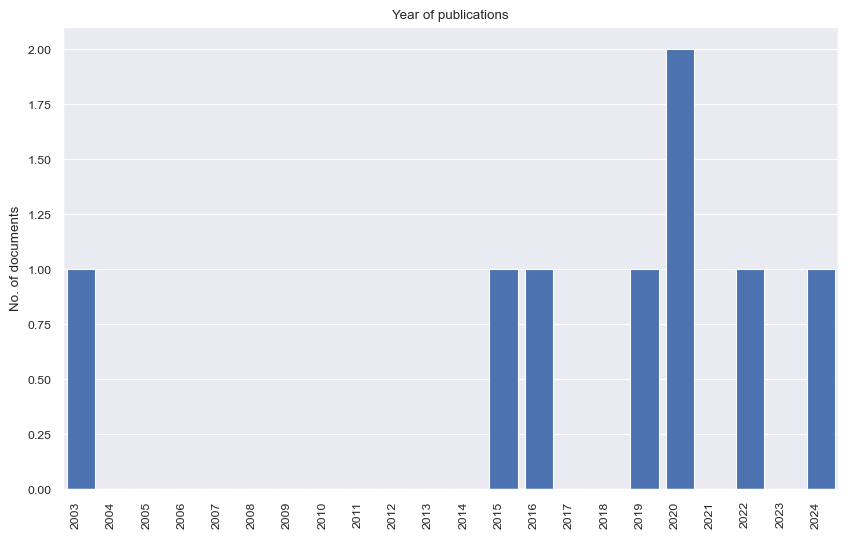

In [73]:
litstudy.plot_year_histogram(filtered_docs, vertical=True);

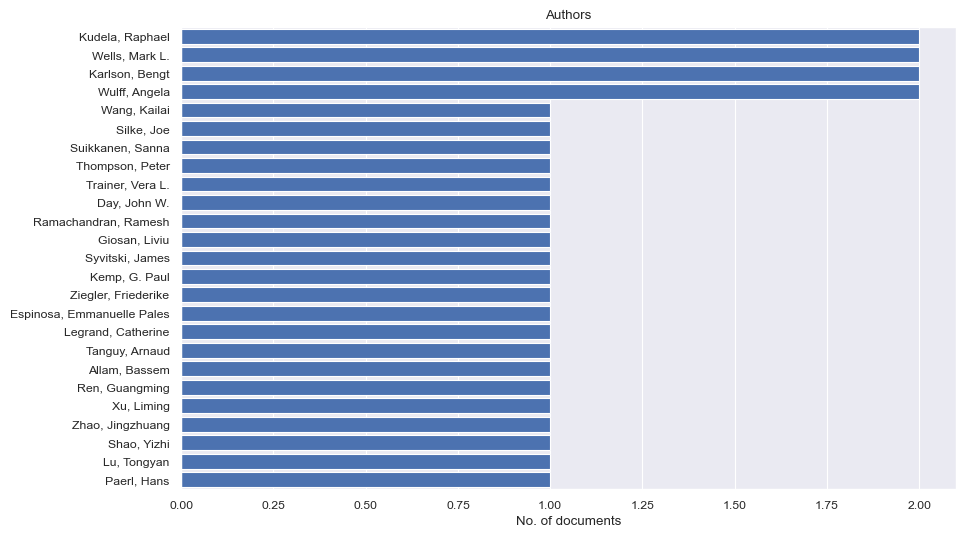

In [44]:
litstudy.plot_author_histogram(filtered_docs);

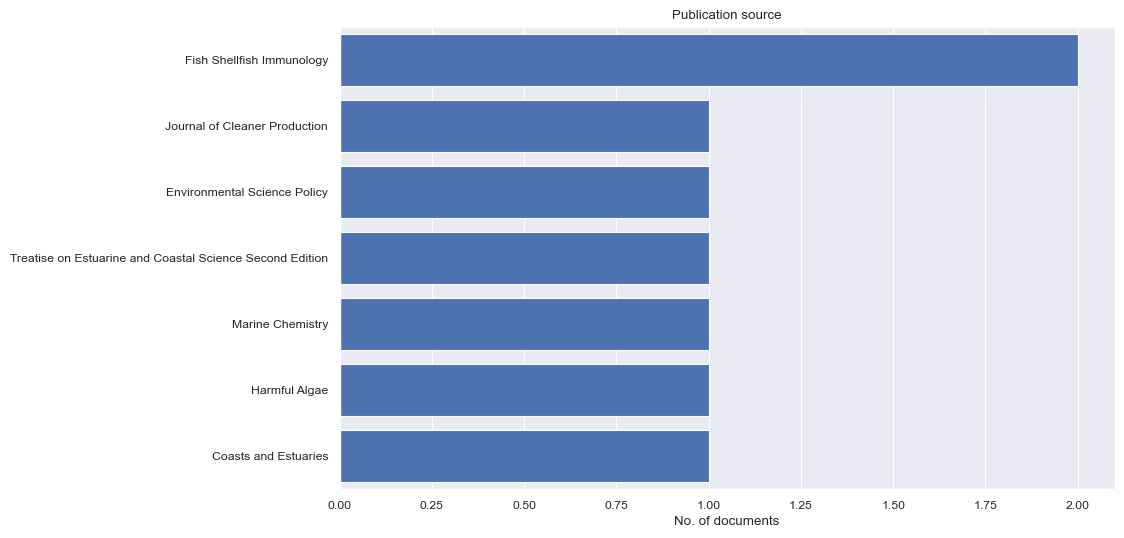

In [46]:
# This names are long, which is why a short abbreviation is provided.
#mapping = {
#    "IEEE International parallel and distributed processing symposium IPDPS": "IEEE IPDPS",
#    "IEEE International parallel and distributed processing symposium workshops IPDPSW": "IEEE IPDPS Workshops",
#}

litstudy.plot_source_histogram(filtered_docs, limit=50);

In [47]:
corpus = litstudy.build_corpus(filtered_docs, ngram_threshold=0.8)


In [48]:
litstudy.compute_word_distribution(corpus).filter(like='_', axis=0).sort_index()


,count


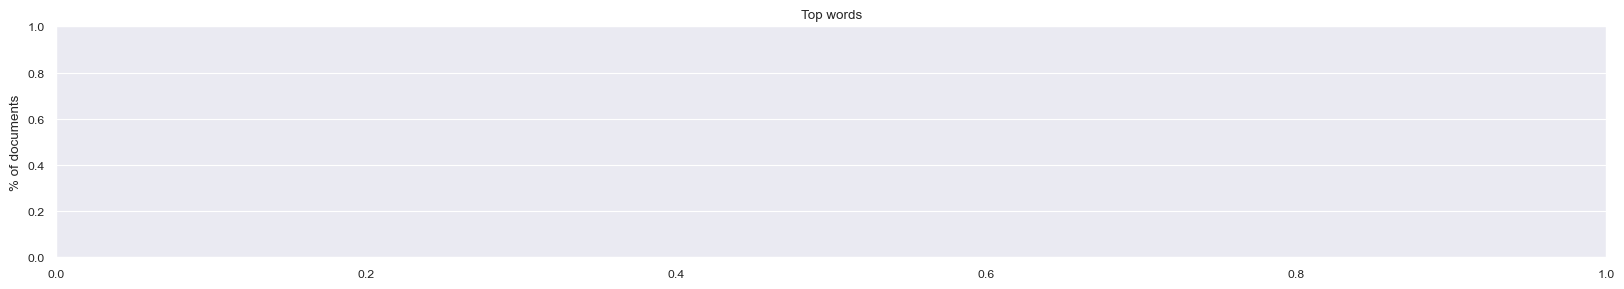

In [51]:
plt.figure(figsize=(20, 3))
litstudy.plot_word_distribution(corpus, limit=50, title="Top words", vertical=True, label_rotation=45);

In [49]:
num_topics = 15
topic_model = litstudy.train_nmf_model(corpus, num_topics, max_iter=250)

ZeroDivisionError: float division by zero

In [50]:
plt.figure(figsize=(15, 5))
litstudy.plot_topic_clouds(topic_model, ncols=5);

NameError: name 'topic_model' is not defined

<Figure size 1500x500 with 0 Axes>

In [17]:
# The metadata can be reviewed and manually modified. If you need to make adjustments, you can directly edit the bibfile.data, which is a DataFrame containing all the utilized information.
print(tabulate(bibfile.data.head(n = 10), headers = 'keys ', tablefmt = 'psql'))
# Modify 'bibfile.data' as needed.

+----+---------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [18]:
# Check Docs IDs
data_table.DataTable(bibfile.table_id_doc, num_rows_per_page = 15)

NameError: name 'data_table' is not defined

In [53]:
# Iterate and print each article
for i, doc in enumerate(filtered_docs, 1):
    authors = ", ".join([a.name for a in getattr(doc, "authors", [])])
    title = getattr(doc, "title", "")
    year = getattr(doc, "year", "")
    journal = getattr(doc, "journal", "")
    abstract = getattr(doc, "abstract", "")
    
    print(f"Article {i}")
    print(f"Title   : {title}")
    print(f"Authors : {authors}")
    print(f"Year    : {year}")
    print(f"Journal : {journal}")
    print(f"Abstract: {abstract[:200]}...")  # print first 200 chars
    print("-" * 80)

Article 1
Title   : Emissions from fuel combustion in Swedish cod fishery
Authors : Ziegler, Friederike, Hansson, Per-Anders
Year    : 
Journal : 
Abstract: This study presents emission data (CO2, NOx, CO, HC and SOx) for fishing vessels, calculated per kg of cod landed by Swedish fishermen. Three scenarios are included; one reflecting the fishery and fle...
--------------------------------------------------------------------------------
Article 2
Title   : Adaptive capacity and coping strategies of small-scale coastal fisheries to declining fish catches: Insights from Tanzanian communities
Authors : Silas, Mathew O., Mgeleka, Said S., Polte, Patrick, Sköld, Mattias, Lindborg, Regina, Torre-Castro, Maricela de la, Gullström, Martin
Year    : 
Journal : 
Abstract: Small-scale fishing communities are expected to adapt to fish catch fluctuations linked to global environmental change. Notwithstanding, impacts from severe climate events and overexploitation of fish...
----------------------

In [54]:
for i, doc in enumerate(filtered_docs, 1):
    print(f"Article {i}")
    for attr in dir(doc):
        # Skip internal/private attributes
        if attr.startswith("_"):
            continue
        
        value = getattr(doc, attr)
        
        # Convert lists of BibAuthor to string
        if isinstance(value, list):
            if len(value) > 0 and hasattr(value[0], "name"):
                value = ", ".join([a.name for a in value])
        
        # Avoid printing methods
        if callable(value):
            continue
        
        print(f"{attr}: {value}")
    print("-" * 80)

Article 1
abstract: This study presents emission data (CO2, NOx, CO, HC and SOx) for fishing vessels, calculated per kg of cod landed by Swedish fishermen. Three scenarios are included; one reflecting the fishery and fleet of 1999, one assuming modern engine technology and, finally, a future scenario assuming a slight increase in the use of passive gear (seines and long-lines) and pair trawls instead of single trawls, lower fishing effort and lower emission levels. The effects on the results of different allocation strategies for landed by-catches are evaluated. Data was gathered from official fishery statistics and engine emission data from one of the major manufacturers of marine diesels. Fuel consumption data for otter trawling and gillnet fishing was obtained by having fishermen fill out a questionnaire. The results include emission calculations for gillnet fishing and trawling, and indicate lower emissions per kg of cod caught for gillnet fishing, due to lower fuel consumption. Co

In [60]:
for doc in filtered_docs:
    row = {}
    for attr in dir(doc):
        # Skip private/internal attributes
        if attr.startswith("_"):
            continue
        value = getattr(doc, attr)
        # Skip methods
        if callable(value):
            continue
        # Convert list of BibAuthor to string
        if isinstance(value, list) and len(value) > 0 and hasattr(value[0], "name"):
            value = ", ".join([a.name for a in value])
        row[attr] = value
    articles_data.append(row)

# Create DataFrame: each row = article, each column = attribute
df_articles = pd.DataFrame(articles_data)

# Optional: inspect the DataFrame
print(df_articles.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   abstract            40 non-null     object
 1   affiliations        40 non-null     object
 2   authors             40 non-null     object
 3   citation_count      0 non-null      object
 4   citations           0 non-null      object
 5   entry               40 non-null     object
 6   id                  40 non-null     object
 7   key                 40 non-null     object
 8   keywords            40 non-null     object
 9   language            0 non-null      object
 10  publication_date    40 non-null     object
 11  publication_month   0 non-null      object
 12  publication_source  40 non-null     object
 13  publication_year    40 non-null     int64 
 14  publisher           10 non-null     object
 15  references          0 non-null      object
 16  source_type         0 non-nu